# Sentiment Analysis with a Feedforward ANN

We classify Amazon product reviews as **positive (1)** or **negative (0)** using a
TF-IDF bag-of-words representation fed into a simple feedforward neural network.

**Pipeline overview**
```
Raw text  →  Preprocessing  →  TF-IDF vectors  →  ANN  →  {0, 1}
```

## Setup & Imports

Standard scientific Python stack plus PyTorch for the neural network, scikit-learn for TF-IDF and SVD, and a small set of project-local helpers (`data_loading_code`, `utils`) that contain the model definition, training loop, and evaluation utilities.

Global flags control optional Weights & Biases logging — set `LOG_WANDB = False` to run fully offline.

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from data_loading_code import preprocess_pandas
from utils import device_check, fit, evaluate, SentimentANN, save_ann_run
from plotting_tools import plot_confusion_matrix

# Suppress NumPy 2.4 VisibleDeprecationWarning triggered inside torchvision
warnings.filterwarnings("ignore", category=np.exceptions.VisibleDeprecationWarning)

device = device_check()

PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


In [ ]:
LOG_WANDB   = True  # Set False to disable wandb logging
WANDB_DIR   = Path(__file__).parent.parent
SPLITS_DIR  = Path(__file__).parent.parent / 'data' / 'splits'

NUM_WORKERS = min(4, os.cpu_count() or 0)
PIN_MEMORY  = True
SEED = 1

# Make results reproducible
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

---
## Initial Test — 1 K Amazon Reviews

### Load Pre-split Data

In [ ]:
train_df = pd.read_csv(SPLITS_DIR / '1k_train.csv')
val_df   = pd.read_csv(SPLITS_DIR / '1k_val.csv')
test_df  = pd.read_csv(SPLITS_DIR / '1k_test.csv')

# Preprocess text for TF-IDF (lowercase, remove punctuation/digits/stopwords)
train_df = preprocess_pandas(train_df)
val_df   = preprocess_pandas(val_df)
test_df  = preprocess_pandas(test_df)

X_train = train_df['Sentence'].values.astype('U')
X_val   = val_df['Sentence'].values.astype('U')
X_test  = test_df['Sentence'].values.astype('U')
y_train = train_df['Class'].values.astype('int32')
y_val   = val_df['Class'].values.astype('int32')
y_test  = test_df['Class'].values.astype('int32')

print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

Train: 810  |  Val: 90  |  Test: 100


### TF-IDF Vectorization

TF-IDF stands for Term Frequency–Inverse Document Frequency. The core idea is to represent each review as a fixed-length numeric vector where each position corresponds to a word (or word pair), and the value captures how distinctive that word is for that particular review.
The two components are:

1. TF (Term Frequency) — how often a word appears in this review. A review that says "great" three times scores higher on "great" than one that says it once.
2. IDF (Inverse Document Frequency) — a penalty for words that appear in most reviews. A word like "phone" appears in almost every review, so it tells you very little about sentiment and gets down-weighted. A word like "worthless" appears rarely and is much more informative.

Multiply them together, and you get a score that's high for words that are frequent in this review but rare across the dataset — exactly the words that carry signal.

The vectorizer is **fit only on the training set** to avoid data leakage, then used
to transform all three splits.

In [4]:
vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=20_000,
    min_df=2,
    max_df=0.85,
    sublinear_tf=True,
    norm='l2',
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'TF-IDF features: {X_train_tfidf.shape[1]:,}')

TF-IDF features: 727


### Truncated SVD (LSA)

TF-IDF gives us a very high-dimensional sparse vector per review. Most of those dimensions are near-zero for any given review.
**Truncated SVD** — also known as **Latent Semantic Analysis (LSA)** when applied
to text — compresses this into a dense, lower-dimensional representation by finding
the directions of greatest variance in the data.

Concretely, it factorises the TF-IDF matrix $X$ as:

$$X \approx U \Sigma V^T$$

and keeps only the top $k$ singular vectors, projecting each review into a
$k$-dimensional space where nearby points share similar vocabulary patterns.

Key differences from PCA:
- Works **directly on sparse matrices** (no centering required), which is critical
  for efficiency with TF-IDF output.
- The resulting dimensions capture latent **topics** rather than individual words.

Like the vectorizer, SVD is **fit only on the training set** to prevent data leakage.

In [5]:
N_COMPONENTS = 300

svd = TruncatedSVD(n_components=N_COMPONENTS, n_iter=5, random_state=SEED)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd   = svd.transform(X_val_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)

print(f'SVD: {X_train_tfidf.shape[1]:,} → {N_COMPONENTS} components  '
      f'({svd.explained_variance_ratio_.sum():.1%} variance explained)')

X_train_t = torch.from_numpy(X_train_svd).float()
X_val_t   = torch.from_numpy(X_val_svd).float()
X_test_t  = torch.from_numpy(X_test_svd).float()

y_train_t = torch.from_numpy(y_train).long()
y_val_t   = torch.from_numpy(y_val).long()
y_test_t  = torch.from_numpy(y_test).long()

INPUT_DIM = N_COMPONENTS

SVD: 727 → 300 components  (86.0% variance explained)


### DataLoaders

The SVD-compressed numpy arrays are converted to `float32` tensors and wrapped in `TensorDataset` objects, then handed off to PyTorch `DataLoader`. Only the training loader shuffles; validation and test loaders iterate in fixed order so metrics are reproducible.

In [6]:
BATCH_SIZE = 64

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

### Model Architecture

A three-layer feedforward network with **BatchNorm** and **Dropout** for regularization.

```
Input (vocab_size)  →  FC(256) → BN → ReLU → Dropout
                    →  FC(64)  → BN → ReLU → Dropout
                    →  FC(2)   →  logits
```

In [7]:
HIDDEN_DIMS = [256, 64]
DROPOUT = 0.3

model = SentimentANN(
    input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS,
    num_classes=2, dropout=DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Trainable parameters: 94,274


### Training

The model is trained with **Adam** and **cross-entropy loss** for 100 epochs. The custom `fit` helper logs train/val loss and accuracy each epoch, saves the best checkpoint by validation accuracy, and optionally streams metrics to W&B.

In [ ]:
NUM_EPOCHS    = 100
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

wandb_kwargs = dict(
    entity="d7047e-group12",
    project="Lab1",
    name="TFIDF + SVD ANN 1K",
    tags=["Task 1.1", "ANN", "TFIDF", "SVD", "1K"],
    dir=WANDB_DIR,
    config={
        "dataset": "Amazon 1K",
        "optimizer": optimizer,
        "hidden_dims": HIDDEN_DIMS,
        "weight_decay": WEIGHT_DECAY,
        'dropout': DROPOUT,
        "lr": LEARNING_RATE,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
    },
)

_ = fit(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs=wandb_kwargs,
    log=LOG_WANDB,
    patience=10,
)


_ = save_ann_run(
    out_dir='../models/ann_1k',
    model=model,
    vectorizer=vectorizer,
    svd=svd,
    input_dim=INPUT_DIM,
    hidden_dims=HIDDEN_DIMS,
    num_classes=2,
    dropout=DROPOUT,
)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: oscar-engelmark (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


  Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
  1/100 |     0.7541 |     50.12% |     0.6982 |     50.00%
  2/100 |     0.7050 |     55.56% |     0.6927 |     50.00%
  3/100 |     0.6765 |     58.89% |     0.6757 |     54.44%
  4/100 |     0.6551 |     61.11% |     0.6472 |     72.22%
  5/100 |     0.6232 |     65.19% |     0.6160 |     72.22%
 10/100 |     0.5166 |     74.94% |     0.5590 |     77.78%
 15/100 |     0.4179 |     84.32% |     0.5325 |     77.78%
 20/100 |     0.3489 |     90.00% |     0.5163 |     78.89%
 25/100 |     0.2879 |     91.48% |     0.5042 |     78.89%
 30/100 |     0.2414 |     92.96% |     0.4981 |     78.89%
 35/100 |     0.2064 |     94.44% |     0.5021 |     80.00%
 40/100 |     0.1754 |     95.43% |     0.5075 |     77.78%

Early stopping triggered at epoch 40 (no improvement for 10 epochs)

Restored best weights (val loss 0.4981)


Training Accuracy,▁▂▂▃▃▄▄▅▅▅▅▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇█████████████
Training Loss,█▇▇▇▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
Validation Accuracy,▁▁▂▆▆▆▆▇▇▇█▇▇▇▇▇▇▇██▇▇█████████████████▇
Validation Loss,██▇▆▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Training Accuracy,95.4321
Training Loss,0.17543
Validation Accuracy,77.77778
Validation Loss,0.50745
test_accuracy,74
test_loss,0.51015
test_macro_f1,0.73833


ANN run saved to: ../models/ann_1k


### Evaluation on the Test Set

The saved best checkpoint is loaded and run on the held-out test set. `evaluate` reports overall accuracy, per-class precision / recall / F1, and macro-averaged scores. The confusion matrix in the next cell gives a visual breakdown of misclassifications.

In [ ]:
_ = evaluate(
    model,
    test_loader,
    criterion,
    label='ANN TF-IDF + SVD — 1K Samples',
    class_names=['Negative', 'Positive'],
)

Classification Report: ANN TF-IDF + SVD — 1K Samples
              precision    recall  f1-score   support

    Negative      0.707     0.820     0.759        50
    Positive      0.786     0.660     0.717        50

    accuracy                          0.740       100
   macro avg      0.746     0.740     0.738       100
weighted avg      0.746     0.740     0.738       100



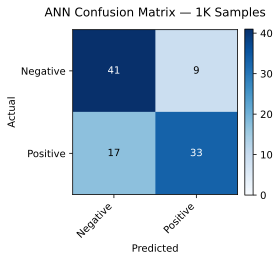

In [10]:
plot_confusion_matrix(
    model=model,
    loader=test_loader,
    num_classes=2,
    class_names=['Negative', 'Positive'],
    title='ANN Confusion Matrix — 1K Samples',
)

---
## Scaling Up — 25 K Amazon Reviews

We now repeat the **exact same pipeline** on the larger `amazon_cells_labelled_LARGE_25K.txt` dataset (same tab-separated format, same binary labels).  The vectoriser and model are retrained **from scratch** on this corpus so the vocabulary properly reflects the larger training distribution.

### Load Pre-split Data

Same CSV format as the 1 K experiment; the splits were generated from the full `amazon_cells_labelled_LARGE_25K.txt` corpus (25 000 reviews).

In [11]:
train_df = pd.read_csv(SPLITS_DIR / '25k_train.csv')
val_df   = pd.read_csv(SPLITS_DIR / '25k_val.csv')
test_df  = pd.read_csv(SPLITS_DIR / '25k_test.csv')

# Preprocess text for TF-IDF (lowercase, remove punctuation/digits/stopwords)
train_df = preprocess_pandas(train_df)
val_df   = preprocess_pandas(val_df)
test_df  = preprocess_pandas(test_df)

X_train = train_df['Sentence'].values.astype('U')
X_val   = val_df['Sentence'].values.astype('U')
X_test  = test_df['Sentence'].values.astype('U')
y_train = train_df['Class'].values.astype('int32')
y_val   = val_df['Class'].values.astype('int32')
y_test  = test_df['Class'].values.astype('int32')

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

Train: 20,250  |  Val: 2,250  |  Test: 2,500


### TF-IDF Vectorisation

Same configuration as the 1 K run but with a wider vocabulary and a stricter `min_df`.

In [12]:
vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=75_000,
    min_df=5,
    max_df=0.85,
    sublinear_tf=True,
    norm='l2',
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'TF-IDF features: {X_train_tfidf.shape[1]:,}')

TF-IDF features: 7,026


In [13]:
N_COMPONENTS = 1000

svd = TruncatedSVD(n_components=N_COMPONENTS, n_iter=5, random_state=SEED)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd   = svd.transform(X_val_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)

print(f'SVD: {X_train_tfidf.shape[1]:,} → {N_COMPONENTS} components  '
      f'({svd.explained_variance_ratio_.sum():.1%} variance explained)')

X_train_t = torch.from_numpy(X_train_svd).float()
X_val_t   = torch.from_numpy(X_val_svd).float()
X_test_t  = torch.from_numpy(X_test_svd).float()

y_train_t = torch.from_numpy(y_train).long()
y_val_t   = torch.from_numpy(y_val).long()
y_test_t  = torch.from_numpy(y_test).long()

INPUT_DIM = N_COMPONENTS

SVD: 7,026 → 1000 components  (56.7% variance explained)


### DataLoaders

In [14]:
BATCH_SIZE = 512

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

### Model, Training & Evaluation

The same two-hidden-layer architecture `[256, 64]` is reused, retrained **from scratch** on the 25 K training split.

In [ ]:
HIDDEN_DIMS    = [256, 64]
ACTIVATION     = nn.ReLU()
DROPOUT        = 0.3
NUM_EPOCHS     = 100
LEARNING_RATE  = 1e-4
WEIGHT_DECAY   = 1e-4

model = SentimentANN(
    input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS,
    num_classes=2, dropout=DROPOUT, activation=ACTIVATION,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

wandb_kwargs = dict(
    entity='d7047e-group12',
    project='Lab1',
    name='TFIDF + SVD ANN 25K',
    tags=['Task 1.1', 'ANN', 'TFIDF', 'SVD', '25K'],
    dir=WANDB_DIR,
    config={
        'dataset': 'Amazon 25K',
        'activation': ACTIVATION,
        'optimizer': optimizer,
        'hidden_dims': HIDDEN_DIMS,
        'num_classes': 2,
        'weight_decay': WEIGHT_DECAY,
        'dropout': DROPOUT,
        'lr': LEARNING_RATE,
        'epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
    },
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5,
)

_ = fit(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs=wandb_kwargs,
    log=LOG_WANDB,
    patience=10,
    scheduler=scheduler,
)


_ = save_ann_run(
    out_dir='../models/ann_25k',
    model=model,
    vectorizer=vectorizer,
    svd=svd,
    input_dim=INPUT_DIM,
    hidden_dims=HIDDEN_DIMS,
    num_classes=2,
    dropout=DROPOUT,
)


  Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
  1/100 |     0.6685 |     59.55% |     0.6732 |     64.22%
  2/100 |     0.5788 |     70.66% |     0.5538 |     80.80%
  3/100 |     0.5042 |     77.04% |     0.4534 |     83.07%
  4/100 |     0.4345 |     82.05% |     0.4059 |     85.07%
  5/100 |     0.3920 |     84.09% |     0.3771 |     85.69%
 10/100 |     0.2840 |     88.44% |     0.3312 |     85.91%
 15/100 |     0.2284 |     91.27% |     0.3303 |     86.22%
 20/100 |     0.1778 |     93.44% |     0.3355 |     86.09%
 24/100 |     0.1547 |     94.60% |     0.3401 |     85.87%

Early stopping triggered at epoch 24 (no improvement for 10 epochs)

Restored best weights (val loss 0.3279)


Training Accuracy,▁▃▄▅▆▆▆▇▇▇▇▇▇▇▇▇▇███████
Training Loss,█▇▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
Validation Accuracy,▁▆▇█████████████████████
Validation Loss,█▆▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Training Accuracy,94.60247
Training Loss,0.15474
Validation Accuracy,85.86667
Validation Loss,0.34011
test_accuracy,84.48
test_loss,0.33299
test_macro_f1,0.8386


ANN run saved to: ../models/ann_25k


### Test-Set Evaluation & Confusion Matrix

Test metrics and the confusion matrix summarise how well the model trained on 25 K samples generalises.

In [16]:
_ = evaluate(
    model,
    test_loader,
    criterion,
    label='ANN TF-IDF + SVD — 25K Samples',
    class_names=['Negative', 'Positive'],
)


Classification Report: ANN TF-IDF + SVD — 25K Samples
              precision    recall  f1-score   support

    Negative      0.794     0.821     0.807       988
    Positive      0.880     0.860     0.870      1512

    accuracy                          0.845      2500
   macro avg      0.837     0.841     0.839      2500
weighted avg      0.846     0.845     0.845      2500



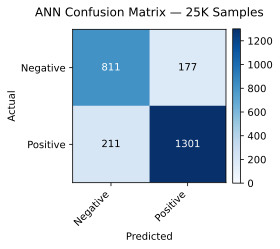

In [17]:
plot_confusion_matrix(
    model=model,
    loader=test_loader,
    num_classes=2,
    class_names=['Negative', 'Positive'],
    title='ANN Confusion Matrix — 25K Samples',
)

---
## Video Games Reviews — 5-Class Rating

Same pipeline applied to the Video Games dataset. The key differences from the
binary sentiment tasks are:
- **5 output classes** (star ratings 1–5), remapped to 0–4 for `CrossEntropyLoss`.
- **Larger corpus** (~2.56 M reviews) so we use a bigger vocabulary and batch size.
- **Imbalanced classes** — 5-star reviews are ~58 % of the data.

### Load Pre-split Data

The Video Games dataset is substantially larger (~2.56 M reviews) so the pre-split CSVs are bigger on disk. Labels are raw star ratings (1–5), remapped to 0–4 inside `preprocess_pandas` before being converted to tensors.

In [18]:
train_df = pd.read_csv(SPLITS_DIR / 'vg_train.csv')
val_df   = pd.read_csv(SPLITS_DIR / 'vg_val.csv')
test_df  = pd.read_csv(SPLITS_DIR / 'vg_test.csv')

# Preprocess text for TF-IDF (lowercase, remove punctuation/digits/stopwords)
# Note: on ~2.56 M reviews this takes a few minutes
train_df = preprocess_pandas(train_df)
val_df   = preprocess_pandas(val_df)
test_df  = preprocess_pandas(test_df)

X_train = train_df['Sentence'].values.astype('U')
X_val   = val_df['Sentence'].values.astype('U')
X_test  = test_df['Sentence'].values.astype('U')

# Remap star ratings 1-5 -> 0-4 (CrossEntropyLoss requires 0-indexed targets)
y_train = (np.asarray(train_df['Class'], dtype='int32') - 1)
y_val   = (np.asarray(val_df['Class'],   dtype='int32') - 1)
y_test  = (np.asarray(test_df['Class'],  dtype='int32') - 1)

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

Train: 2,076,462  |  Val: 230,719  |  Test: 256,354


### TF-IDF Vectorization

In [19]:
vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=100_000,
    min_df=20,
    max_df=0.85,
    sublinear_tf=True,
    norm='l2',
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'TF-IDF features: {X_train_tfidf.shape[1]:,}')

TF-IDF features: 100,000


In [20]:
N_COMPONENTS = 300

svd = TruncatedSVD(n_components=N_COMPONENTS, n_iter=2, random_state=SEED)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd   = svd.transform(X_val_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)

print(f'SVD: {X_train_tfidf.shape[1]:,} → {N_COMPONENTS} components  '
      f'({svd.explained_variance_ratio_.sum():.1%} variance explained)')

X_train_t = torch.from_numpy(X_train_svd).float()
X_val_t   = torch.from_numpy(X_val_svd).float()
X_test_t  = torch.from_numpy(X_test_svd).float()

y_train_t = torch.from_numpy(y_train).long()
y_val_t   = torch.from_numpy(y_val).long()
y_test_t  = torch.from_numpy(y_test).long()

INPUT_DIM = N_COMPONENTS

SVD: 100,000 → 300 components  (23.2% variance explained)


### DataLoaders

In [21]:
BATCH_SIZE = 1024

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

### Model, Training & Evaluation

A **deeper** three-hidden-layer architecture `[512, 256, 128]` is used here. **Inverse-frequency class weights** are passed to `CrossEntropyLoss` to counteract the ~58 % 5-star class imbalance, so the model is penalised more heavily for mistakes on minority classes.

In [ ]:
HIDDEN_DIMS   = [512, 256, 128]
ACTIVATION    = nn.ReLU()
DROPOUT       = 0.3
NUM_EPOCHS    = 100
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4

model = SentimentANN(
    input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS,
    num_classes=5, dropout=DROPOUT, activation=ACTIVATION,
).to(device)

# Inverse-frequency class weights to counter the ~58 % 5-star imbalance
class_counts = np.bincount(y_train)
class_weights = torch.tensor(
    (1.0 / class_counts) / (1.0 / class_counts).sum() * len(class_counts),
    dtype=torch.float, device=device,
)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

wandb_kwargs = dict(
    entity='d7047e-group12',
    project='Lab1',
    name='TFIDF + SVD ANN VG',
    tags=['Task 1.1', 'ANN', 'TFIDF', 'SVD', 'VG'],
    dir=WANDB_DIR,
    config={
        'dataset': 'Video Games',
        'activation': ACTIVATION,
        'optimizer': optimizer,
        'hidden_dims': HIDDEN_DIMS,
        'num_classes': 5,
        'weight_decay': WEIGHT_DECAY,
        'dropout': DROPOUT,
        'lr': LEARNING_RATE,
        'epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'class_weights': class_weights.tolist(),
    },
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5,
)

_ = fit(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs=wandb_kwargs,
    log=LOG_WANDB,
    patience=10,
    scheduler=scheduler,
)


_ = save_ann_run(
    out_dir='../models/ann_vg',
    model=model,
    vectorizer=vectorizer,
    svd=svd,
    input_dim=INPUT_DIM,
    hidden_dims=HIDDEN_DIMS,
    num_classes=5,
    dropout=DROPOUT,
)


  Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
  1/100 |     1.2553 |     53.25% |     1.1754 |     57.58%
  2/100 |     1.1889 |     57.89% |     1.1569 |     57.89%
  3/100 |     1.1722 |     58.74% |     1.1465 |     59.01%
  4/100 |     1.1614 |     59.24% |     1.1405 |     59.29%
  5/100 |     1.1540 |     59.59% |     1.1344 |     60.05%
 10/100 |     1.1319 |     60.38% |     1.1231 |     60.51%
 15/100 |     1.1192 |     60.70% |     1.1183 |     60.78%
 20/100 |     1.1095 |     60.95% |     1.1158 |     60.83%
 25/100 |     1.1024 |     61.05% |     1.1157 |     60.52%
 30/100 |     1.0908 |     61.37% |     1.1145 |     60.73%
 35/100 |     1.0856 |     61.45% |     1.1155 |     60.44%
 40/100 |     1.0801 |     61.54% |     1.1168 |     60.64%

Early stopping triggered at epoch 40 (no improvement for 10 epochs)

Restored best weights (val loss 1.1145)


Training Accuracy,▁▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████████████
Training Loss,█▅▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
Validation Accuracy,▁▂▄▄▆▅▇▇▇▆▆▆▇▇▇▆▇▇▇▇█▆█▆▆█▆▆▇▇▆█▇█▆▇▇▇▇▇
Validation Loss,█▆▅▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Training Accuracy,61.53688
Training Loss,1.08009
Validation Accuracy,60.63957
Validation Loss,1.11676
test_accuracy,60.78119
test_loss,1.11432
test_macro_f1,0.48562


ANN run saved to: ../models/ann_vg


### Test-Set Evaluation & Confusion Matrix

With 5 classes the confusion matrix is 5×5, making it easy to see which rating buckets the model conflates (adjacent ratings are typically hardest to distinguish). Per-class F1 scores reveal whether the model handles minority classes (1- and 2-star reviews) adequately despite the imbalance correction.

In [23]:
_ = evaluate(
    model,
    test_loader,
    criterion,
    label='ANN TF-IDF + SVD — Video Game Reviews',
    class_names=['★', '★★', '★★★', '★★★★', '★★★★★'],
)


Classification Report: ANN TF-IDF + SVD — Video Game Reviews
              precision    recall  f1-score   support

           ★      0.637     0.684     0.660     31181
          ★★      0.234     0.442     0.306     14131
         ★★★      0.271     0.358     0.308     21230
        ★★★★      0.346     0.419     0.379     41225
       ★★★★★      0.875     0.696     0.775    148587

    accuracy                          0.608    256354
   macro avg      0.472     0.520     0.486    256354
weighted avg      0.675     0.608     0.633    256354



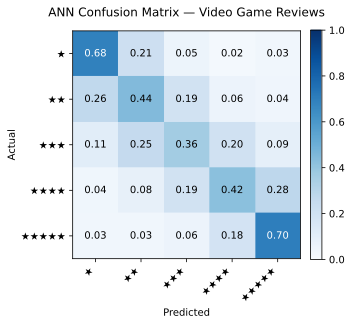

In [24]:
plot_confusion_matrix(
    model=model,
    loader=test_loader,
    num_classes=5,
    class_names=['★', '★★', '★★★', '★★★★', '★★★★★'],
    title='ANN Confusion Matrix — Video Game Reviews',
    normalize=True,
)